## Importation des librairies 

In [ ]:
#Analyse de données

import pandas as pd
import numpy as np

#Visualisation de données

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Préparation de données pour le machine learning

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Modèles de machine learning

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#Métriques d'évaluation des modèles de machine learning

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

from sklearn.metrics import classification_report

#Recherche d'hyperparamètres pour les modèles de machine learning

from sklearn.model_selection import GridSearchCV

## EDA

In [3]:
# Chargement et visualisation des données 

df = pd.read_csv('ecommerce_user_behavior_8000.csv')
df.head()

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [4]:
df.info()
print("----------------------------------------------------------------")
print("Le dataset contient {} lignes et {} colonnes et des valeurs manquantes.".format(df.shape[0], df.shape[1]))
print("Les colonnes 'gender' et 'device_type' contiennent des valeurs catégoriques nominales.")

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   str    
 3   device_type         7840 non-null   str    
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), str(2)
memory usage: 875.1 KB
----------------------------------------------------------------
Le d

In [5]:
df.describe(include='all')

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
count,7840.000000,7840.000000,7840,7840,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000,7840.000000
unique,NaN,NaN,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,Mobile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,3931,4685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4003.135077,38.595791,NaN,NaN,15.714673,9.970026,6.964158,4.530230,0.502551,0.502296,0.509439,15.794999,49.924402,0.998342
std,2307.898984,12.033928,NaN,NaN,8.362764,5.425485,4.281117,2.865814,0.500025,0.500027,0.499943,9.864556,29.137449,0.040689
min,1.000000,18.000000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.570000,0.010000,0.000000
25%,2011.750000,28.000000,NaN,NaN,8.520000,5.000000,3.000000,2.000000,0.000000,0.000000,0.000000,7.750000,24.677500,1.000000
50%,3998.000000,39.000000,NaN,NaN,15.740000,10.000000,7.000000,5.000000,1.000000,1.000000,1.000000,14.300000,49.500000,1.000000
75%,6001.250000,49.000000,NaN,NaN,22.880000,15.000000,11.000000,7.000000,1.000000,1.000000,1.000000,22.392500,75.990000,1.000000


In [32]:
# Doublons

print(f"Le dataset contient {df.duplicated().sum()} doublons.")

Le dataset contient 0 doublons.


In [7]:
#Valeurs manquantes

total_missing = df.isna().sum().sum()
overall_pct = total_missing / df.size * 100
print(df.isna().sum())
print(f"Pourcentage de valeurs manquantes : {overall_pct:.2f}%")

user_id               160
age                   160
gender                160
device_type           160
time_on_site          160
pages_viewed          160
previous_purchases    160
cart_items            160
discount_seen         160
ad_clicked            160
returning_user        160
avg_session_time      160
bounce_rate           160
purchase              160
dtype: int64
Pourcentage de valeurs manquantes : 2.00%


## Analyse univariée

In [8]:
#Variables catégoriques

print("Variables catégoriques nominales :")
print()
print(df["gender"].value_counts())
print()
print(df["device_type"].value_counts())
print()
print("Variables catégoriques binaires :")
print()
print("discount_seen, ad_clicked, returning_user, purchase.")

Variables catégoriques nominales :

gender
Male      3931
Female    3909
Name: count, dtype: int64

device_type
Mobile     4685
Desktop    2365
Tablet      790
Name: count, dtype: int64

Variables catégoriques binaires :

discount_seen, ad_clicked, returning_user, purchase.


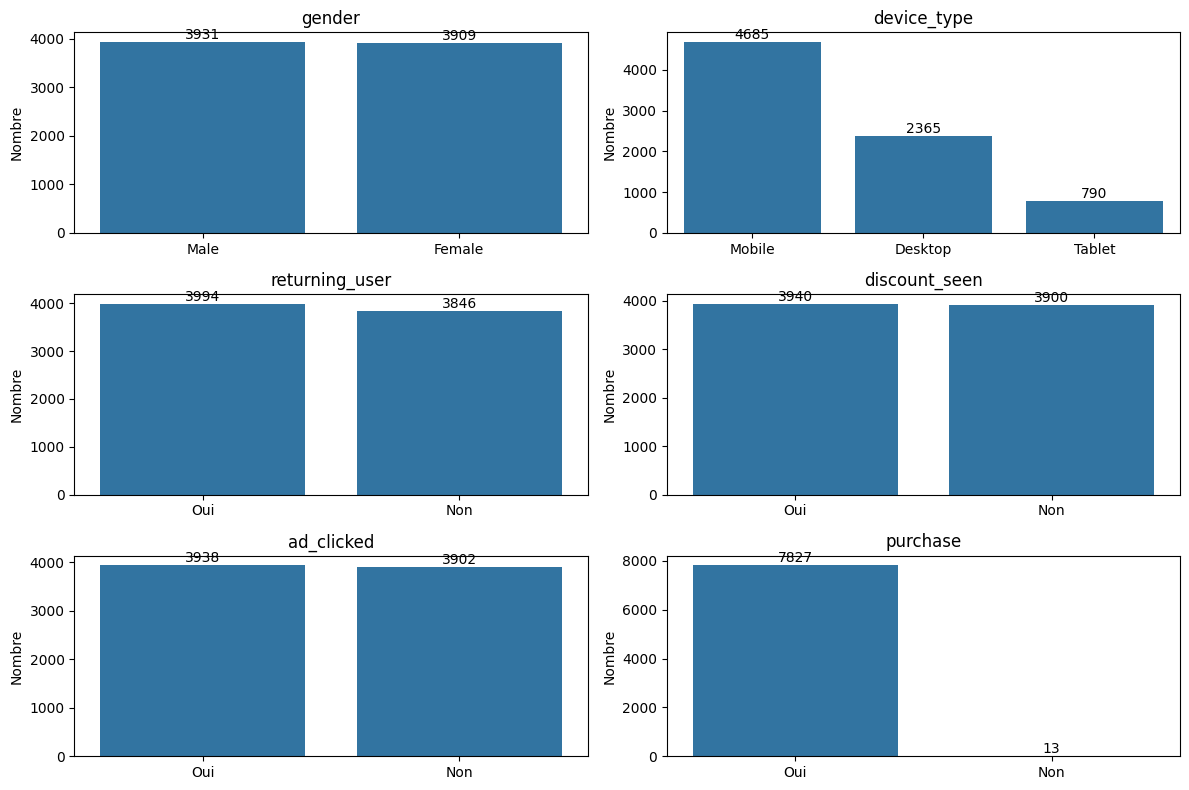

In [9]:
#Visualisation des variables catégoriques

cat_cols = ['gender', 'device_type', 'returning_user', 'discount_seen', 'ad_clicked', 'purchase']

#Conversion des variables binaires codées en 0/1 vers des libellés plus lisibles ("Oui"/"Non")

df["returning_user"] = df["returning_user"].map({
    0: "Non",
    1: "Oui"
})

df["discount_seen"] = df["discount_seen"].map({
    0: "Non",
    1: "Oui"
})

df["ad_clicked"] = df["ad_clicked"].map({
    0: "Non",
    1: "Oui"
})
    
df["purchase"] = df["purchase"].map({
    0: "Non",
    1: "Oui"
})

plt.figure(figsize=(12, 8))

#Boucle sur chaque variable catégorielle

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    
    order = df[col].value_counts().index
    
#Création d'un graphique en barres pour chaque variable catégorielle

    sns.countplot(
        data=df,
        x=col,
        order=order
    )
    
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Nombre")
    

    for container in plt.gca().containers:
        plt.bar_label(container)

plt.tight_layout()
plt.show()

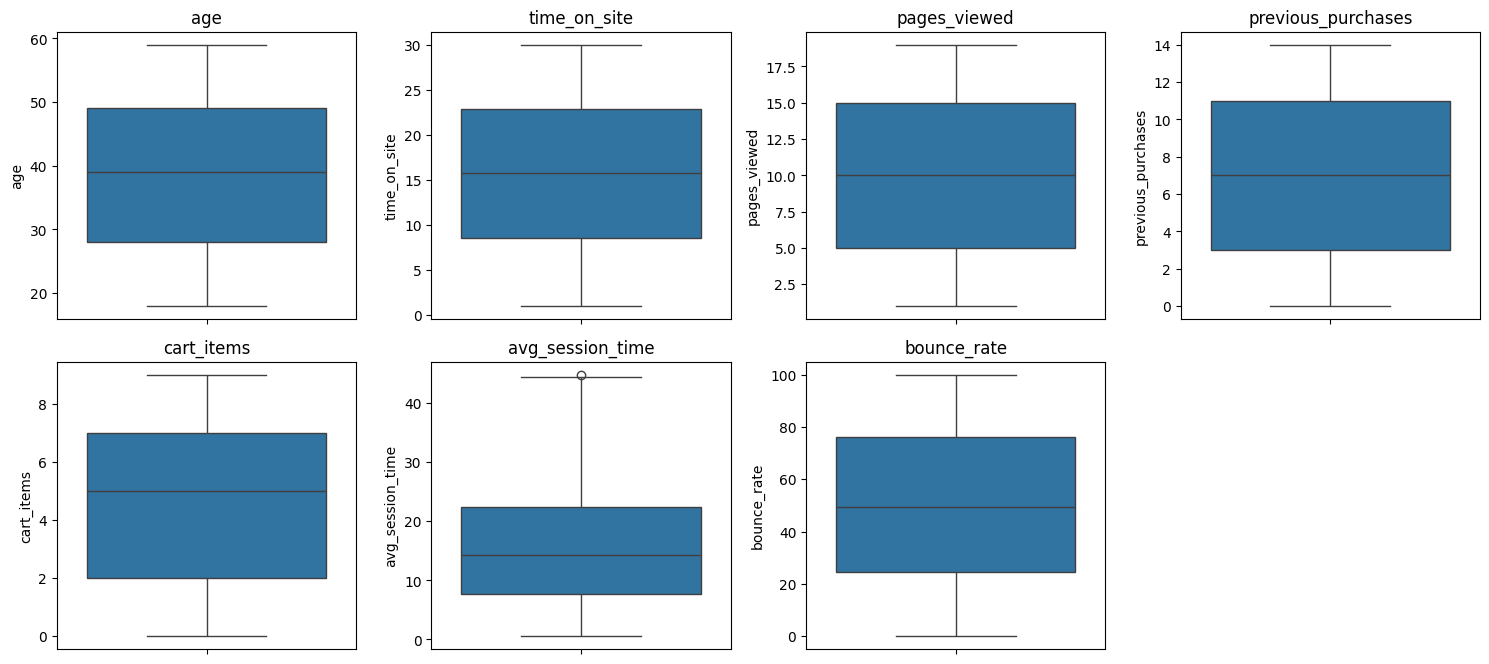

In [10]:
#Détection des valeurs abérantes des variables numériques 

numeric_cols = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'avg_session_time', 'bounce_rate']

plt.figure(figsize=(15, 10))

#Boucle sur chaque variable numérique et création des boxplots

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
#Détection des valeurs aberrantes avec la méthode de l'IQR

#Boucle sur chaque variable numérique

for col in numeric_cols:
    
    # Calcul du premier quartile (Q1 : 25 % des données)
    
    Q1 = df[col].quantile(0.25)
    
    # Calcul du troisième quartile (Q3 : 75 % des données)
    
    Q3 = df[col].quantile(0.75)
    
    # Calcul de l'écart interquartile (IQR) : dispersion des 50 % des données centrales
    
    IQR = Q3 - Q1

    #Définition des bornes inférieure et supérieure selon la règle de 1,5 × IQR
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    #Identification des valeurs aberrantes en dehors des bornes définies

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    #Affichage du nombre de valeurs aberrantes détectées pour chaque variable
    
    print(f"{col}: {len(outliers)} outlier(s)")

age: 0 outlier(s)
time_on_site: 0 outlier(s)
pages_viewed: 0 outlier(s)
previous_purchases: 0 outlier(s)
cart_items: 0 outlier(s)
avg_session_time: 1 outlier(s)
bounce_rate: 0 outlier(s)


La variable avg_session_time est la seule variable contenant des outliers.

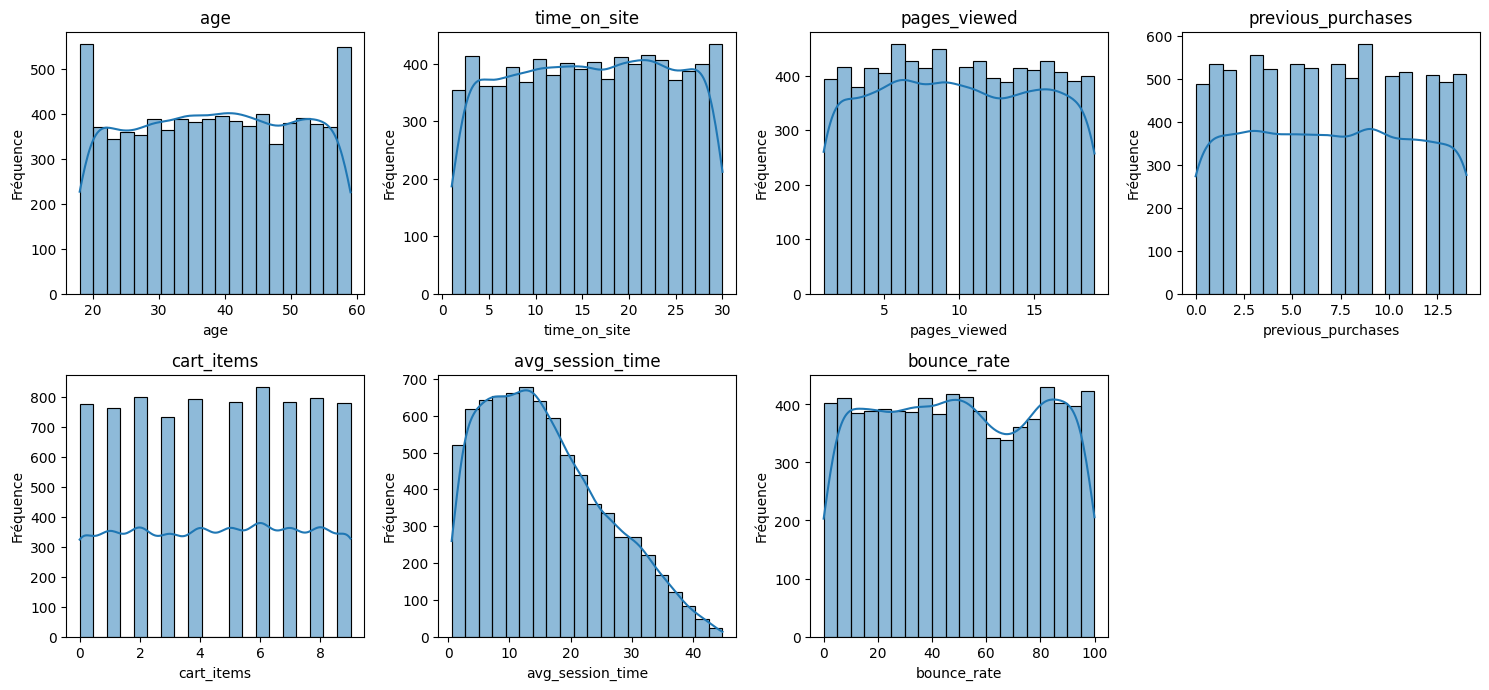

In [12]:
#Distribution des variables numériques

numeric_cols = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'avg_session_time', 'bounce_rate']

plt.figure(figsize=(15, 10))

# Boucle sur chaque variable numérique et création des histogrammes

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()


La majorité des variables numériques présentent une répartition relativement uniforme. La variable avg_session_time présente cependant une distribution asymétrique à droite. Nous constatons une diminution progressive après 13 minutes. 

## Analyse bivariée

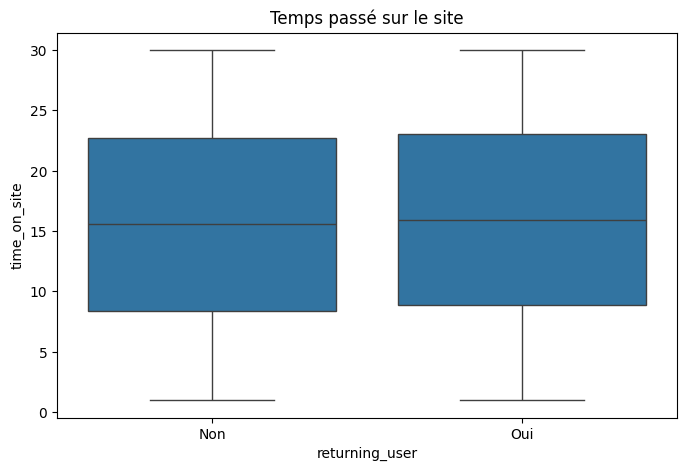

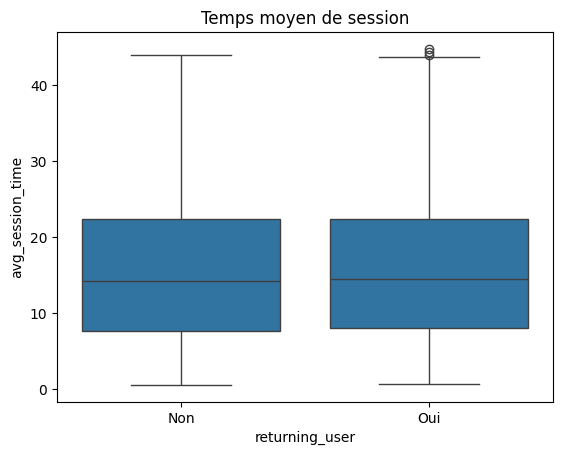

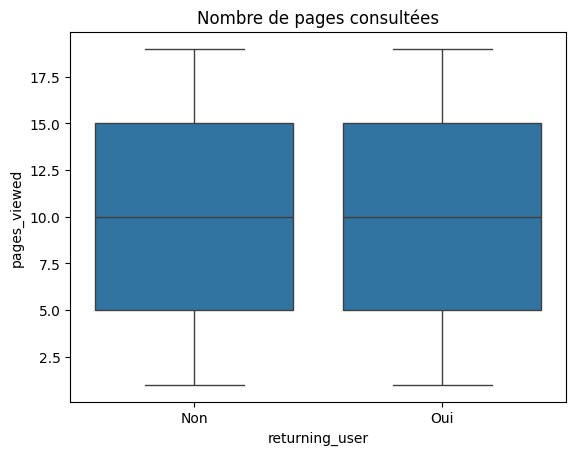

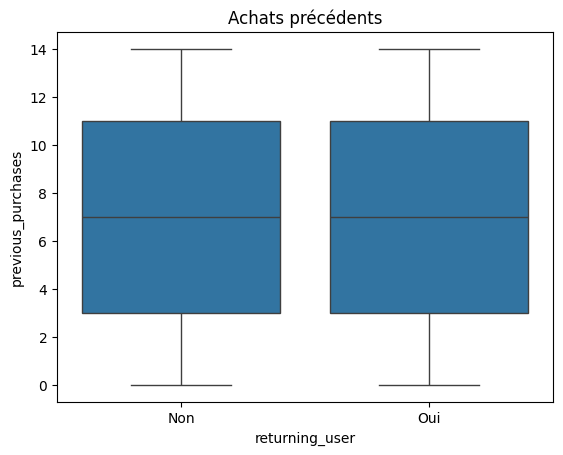

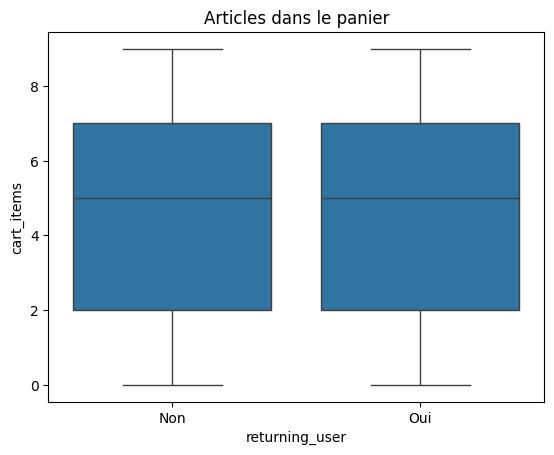

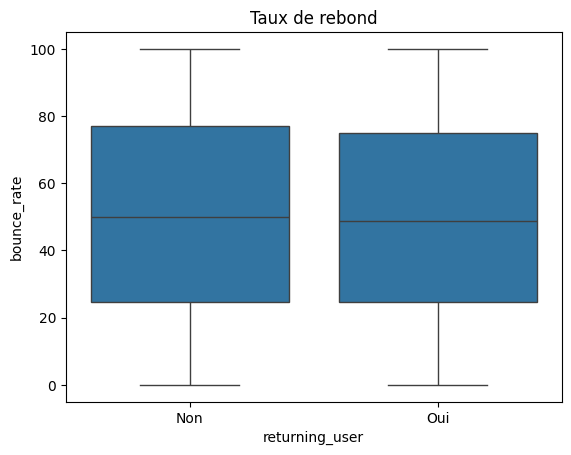

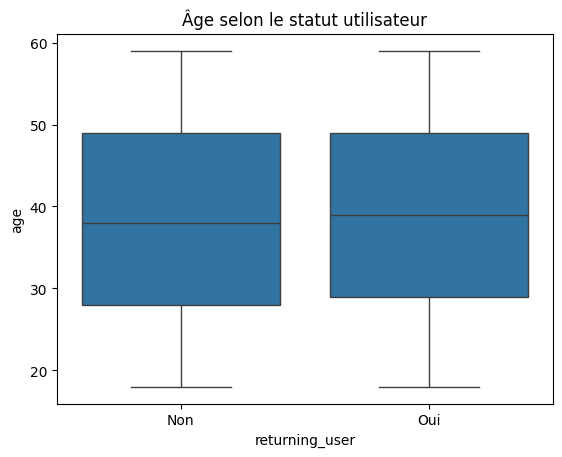

In [13]:
# Relation entre la variable cible 'returning_user' et les variables numériques

#Temps passé sur le site

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="returning_user",
    y="time_on_site"
)

plt.title("Temps passé sur le site")
plt.show()

#Temps moyen de session

sns.boxplot(
    data=df,
    x="returning_user",
    y="avg_session_time"
)

plt.title("Temps moyen de session")
plt.show()

#Nombre de pages consultées

sns.boxplot(
    data=df,
    x="returning_user",
    y="pages_viewed"
)

plt.title("Nombre de pages consultées")
plt.show()

#Nombre d'achats précédents

sns.boxplot(
    data=df,
    x="returning_user",
    y="previous_purchases"
)

plt.title("Achats précédents")
plt.show()

#Nombre d'articles dans le panier

sns.boxplot(
    data=df,
    x="returning_user",
    y="cart_items"
)

plt.title("Articles dans le panier")
plt.show()

#Taux de rebond

sns.boxplot(
    data=df,
    x="returning_user",
    y="bounce_rate"
)

plt.title("Taux de rebond")
plt.show()

#Âge

sns.boxplot(
    data=df,
    x="returning_user",
    y="age"
)

plt.title("Âge selon le statut utilisateur")
plt.show()

Les boxplots montrent des distributions très similaires. Les médianes sont proches et la dispersion des données est comparable. On observe quelques valeurs aberrantes chez les utilisateurs récurrents correspondant à des sessions exceptionnellement longues. Ces cas restent toutefois peu nombreux. 

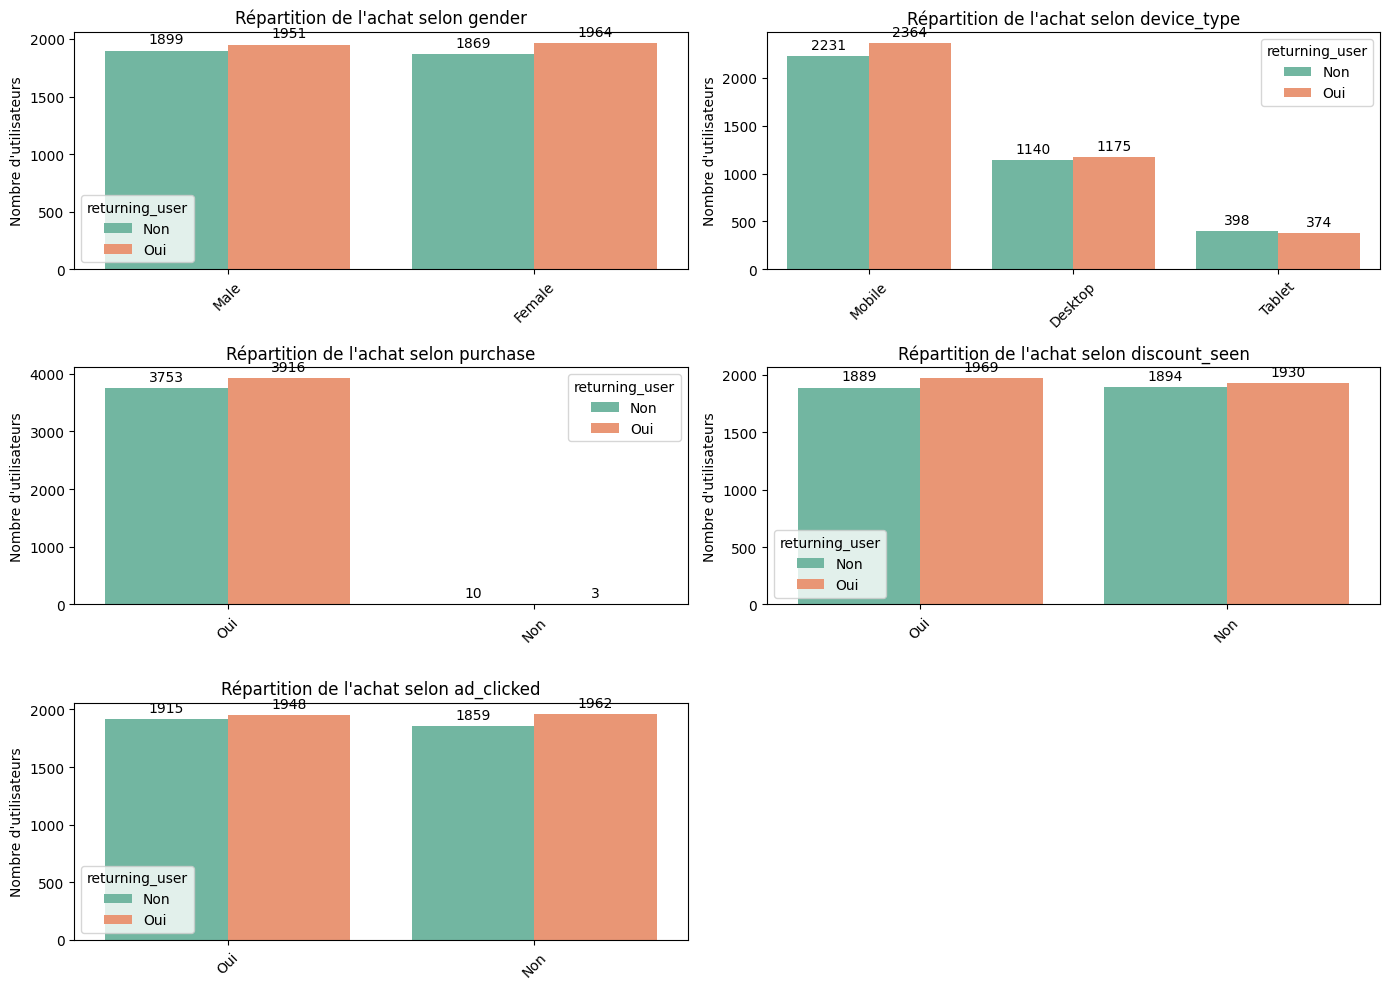

In [14]:
# Relation entre la variable cible 'returning_user' et les variables catégoriques

cat_cols = ['gender', 'device_type','purchase', 'discount_seen', 'ad_clicked']

plt.figure(figsize=(14, 10))

#Boucle sur chaque variable catégorielle et création des graphiques en barres

for i, col in enumerate(cat_cols, 1):

    plt.subplot(3, 2, i)

    order = df[col].value_counts().index

    ax = sns.countplot(
        data=df,
        x=col,
        hue='returning_user',
        order=order,
        palette="Set2"
    )

    plt.title(f"Répartition de l'achat selon {col}")
    plt.xlabel("")
    plt.ylabel("Nombre d'utilisateurs")

#Ajout des valeurs numériques au-dessus de chaque barre
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


L'analyse des variables catégorielles met en évidence des distributions très similaires entre les utilisateurs revenants et les nouveaux utilisateurs. Aucune variable prise individuellement ne permet de distinguer clairement les deux groupes.

## Analyse multivariée


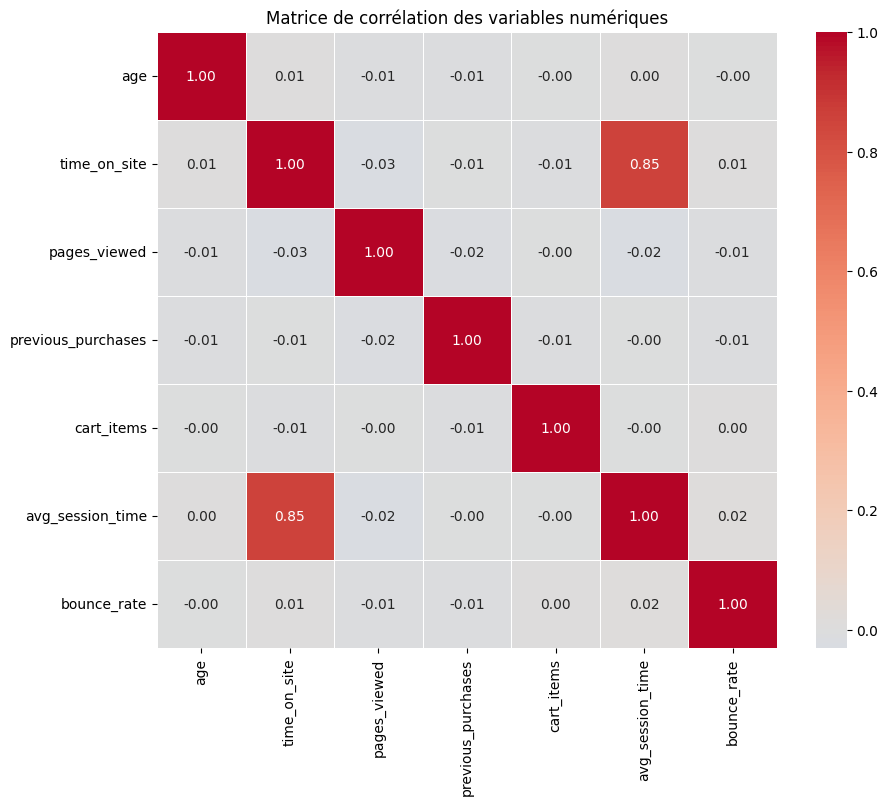

In [15]:
#Analyse des corrélations entre les variables numériques

numeric_cols = [
    'age',
    'time_on_site',
    'pages_viewed',
    'previous_purchases',
    'cart_items',
    'avg_session_time',
    'bounce_rate',
]

#Calcul de la matrice de corrélation 

corr_matrix = df[numeric_cols].corr()

corr_matrix

#Visualisation de la matrice de corrélation

plt.figure(figsize=(10,8))

#Représentation graphique de la matrice de corrélation

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

L'analyse de corrélation révèle des associations linéaires faibles entre les variables numériques. Malgré ces faibles coefficients, les variables comportementales restent pertinentes car leur effet peut apparaître lorsqu'elles sont considérées simultanément dans un modèle multivarié. Par ailleurs, une forte corrélation est observée entre time_on_site et avg_session_time (r = 0,85), indiquant une possible redondance entre ces deux variables. Une attention particulière devra donc être portée à la multicolinéarité lors de la construction du modèle prédictif.

In [16]:
#Calcul du profil moyen des utilisateurs selon la variable cible 'returning_user'

df.groupby('returning_user')[numeric_cols].mean().round(2)

,age,time_on_site,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate
returning_user,,,,,,,
Non,38.34,15.55,9.90,6.96,4.52,15.73,50.23
Oui,38.85,15.88,10.05,6.97,4.54,15.88,49.55


L'analyse des moyennes montre que les utilisateurs revenants et les non revenants présentent des profils très similaires sur les variables numériques étudiées. Les écarts observés sont faibles et ne permettent pas de distinguer clairement les deux groupes à partir d'une seule variable.

## Préparation des données pour le machine learning

In [17]:
# Suppression des colonnes (variables corélées et colonne ID)

drop_cols = ['avg_session_time', 'user_id']
df.drop(columns=drop_cols, inplace=True)

In [18]:
# Suppression des lignes avec des valeurs manquantes pour la variable cible 'returning_user'

df.dropna(subset=['returning_user'], inplace=True)

In [19]:
# Séparation des variables X de la variable cible Y

target_name = "returning_user"

Y = df.loc[:, target_name]
X = df.drop(target_name, axis=1)

print("La variable cible Y:")
print(Y.head())
print()
print("Les variables X:")
print(X.head())

La variable cible Y:
0    Non
1    Oui
2    Oui
3    Oui
4    Non
Name: returning_user, dtype: str

Les variables X:
    age  gender device_type  time_on_site  pages_viewed  previous_purchases  \
0  56.0  Female     Desktop         12.90           8.0                13.0   
1  46.0    Male      Mobile         15.63           9.0                 4.0   
2  32.0  Female         NaN         11.64          12.0                11.0   
3  25.0  Female      Mobile         22.71           5.0                10.0   
4  38.0  Female      Mobile         26.35           9.0                12.0   

   cart_items discount_seen ad_clicked  bounce_rate purchase  
0         1.0           Oui        NaN        28.18      Oui  
1         6.0           Oui        Oui        86.73      Oui  
2         0.0           Non        Non        83.09      Oui  
3         1.0           Non        Non        79.03      Oui  
4         4.0           Oui        Non        55.35      Oui  


In [20]:
# Séparation du train et du test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y)

print("Séparation des données en train et test :")
print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test : {X_test.shape[0]} échantillons")

Séparation des données en train et test :
Train : 6272 échantillons
Test : 1568 échantillons


In [21]:
# Préparation des variables X
# Standardisation des variables numériques et encodage des variables catégorielles

#Définition des variables numériques

numeric_features = ['age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'bounce_rate']

#Création d'un pipeline de transformation pour les variables numériques
#(standardisation et imputation des valeurs manquantes)

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
             SimpleImputer(strategy="median"),
         ),
        
        ("scaler", StandardScaler()),
    ]
)

#Définition des variables catégorielles

categorical_features = ['gender', 'device_type', 'discount_seen', 'ad_clicked', 'purchase'] 

#Création d'un pipeline de transformation pour les variables catégorielles
#(encodage et imputation des valeurs manquantes)

categorical_transformer = Pipeline(
    steps=[
        ("imputer",
         SimpleImputer(strategy="most_frequent"),
         ),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"),
        ),
    ]
)

#Application des transformations sur les variables numériques et catégorielles

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

#Application du préprocesseur sur les données d'entraînement et de test

# Train set : fit_transform apprend les paramètres de transformation sur X_train et applique ensuite les transformations sur X_train

print("Performing preprocessings on train set...")
X_train = preprocessor.fit_transform(X_train)
print("...Done.")
print(
    X_train[0:5]
) 
print()

# Test set : transform applique les transformations apprises sur X_train à X_test

print("Performing preprocessings on test set...")
X_test = preprocessor.transform(
    X_test
) 
print("...Done.")

# Affichage des 5 premières lignes de X_test après transformation

print(
    X_test[0:5, :]
) 
print()


Performing preprocessings on train set...
...Done.
[[-1.71959024  0.4973405   0.17989591 -0.93584575  1.22890417 -1.13590022
   1.          1.          0.          1.          1.          1.        ]
 [-1.21931487 -0.18709884 -0.5647384  -1.40571643 -0.54110615 -0.08706569
   0.          0.          0.          0.          0.          1.        ]
 [-0.63566027 -1.7153179   0.36605449  1.648443    0.52090004  0.38031212
   1.          1.          0.          0.          1.          1.        ]
 [-0.7190395  -0.43214503  1.48300595 -0.93584575 -0.54110615 -0.54027006
   0.          1.          0.          1.          0.          1.        ]
 [ 0.61502816 -0.03982971  0.36605449  1.41350765  0.52090004 -0.88527232
   1.          1.          0.          1.          0.          1.        ]]

Performing preprocessings on test set...
...Done.
[[-0.7190395   1.58737353 -1.30937271 -1.17078109 -0.54110615  0.97248534
   1.          1.          0.          1.          0.          1.        ]
 [-

In [22]:
#Encodage de la variable cible Y 
#La variable cible catégorielle 'returning_user' est encodée en 0/1 pour l'apprentissage supervisé

labelencoder = LabelEncoder()

#Encodage de la variable cible sur le train set
#Fit_transform apprend la correspondance entre les catégories et les valeurs numériques et applique ensuite la transformation sur Y_train

print("Encoding labels on train set...")
print()
Y_train = labelencoder.fit_transform(Y_train)
print("...Done.")

## Affichage des premières valeurs encodées

print(Y_train[0:5])
print()

#Encodage de la variable cible sur le test set
#Transform applique la correspondance entre les catégories et les valeurs numériques apprise sur Y_train à Y_test

print("Encoding labels on test set...")
print()
Y_test = labelencoder.transform(Y_test)
print("...Done.")

## Affichage des premières valeurs encodées

print(Y_test[0:5])


Encoding labels on train set...

...Done.
[0 0 0 1 0]

Encoding labels on test set...

...Done.
[0 0 1 0 0]


In [23]:
# Entraînement de différents modèles de classification

#Création d'un dictionnaire contenant les différents modèles de classification à comparer.

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

# Boucle d'entraînement de chaque modèle

for name, model in models.items():
    print(f"Entraînement du modèle {name}...")
    
# Apprentissage du modèle sur le jeu d'entraînement (le modèle apprend les relations entre les variables X et la variable cible Y)

    model.fit(X_train, Y_train)
    print("...Done.")

Entraînement du modèle Logistic Regression...
...Done.
Entraînement du modèle Decision Tree...


...Done.
Entraînement du modèle Random Forest...
...Done.
Entraînement du modèle Gradient Boosting...
...Done.
Entraînement du modèle XGBoost...
...Done.


In [24]:
# Évaluation et comparaison des modèles de classification

# Liste pour stocker les résultats

results = []

# Boucle sur chaque modèle entraîné précédemment

for name, model in models.items():
    
#Réalisation des prédictions sur le jeu de test
    
    Y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(Y_test, Y_pred),
        'Precision': precision_score(Y_test, Y_pred),
        'Recall': recall_score(Y_test, Y_pred),
        'F1-score': f1_score(Y_test, Y_pred),
    })

# Création du tableau
results_df = pd.DataFrame(results)

# Trier par F1-score 
results_df = results_df.sort_values(by='F1-score', ascending=False)

# Affichage
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.5108,0.5154,0.6696,0.5825
3,Gradient Boosting,0.5159,0.5210,0.6220,0.5670
4,XGBoost,0.5255,0.5339,0.5419,0.5379
2,Random Forest,0.5038,0.5131,0.5156,0.5144
1,Decision Tree,0.5026,0.5118,0.5169,0.5143


In [25]:
# Rapport de classification pour chaque modèle
# Résumé détaillé des performances du modèle de classification.

for name, model in models.items():

    print("="*50)
    print(f"Classification report : {name}")
    print("="*50)

    Y_pred = model.predict(X_test)

    print(classification_report(
        Y_test,
        Y_pred,
        target_names=["Non revenant", "Utilisateur revenant"]
    ))

Classification report : Logistic Regression
                      precision    recall  f1-score   support

        Non revenant       0.50      0.35      0.41       769
Utilisateur revenant       0.52      0.67      0.58       799

            accuracy                           0.51      1568
           macro avg       0.51      0.51      0.50      1568
        weighted avg       0.51      0.51      0.50      1568

Classification report : Decision Tree
                      precision    recall  f1-score   support

        Non revenant       0.49      0.49      0.49       769
Utilisateur revenant       0.51      0.52      0.51       799

            accuracy                           0.50      1568
           macro avg       0.50      0.50      0.50      1568
        weighted avg       0.50      0.50      0.50      1568

Classification report : Random Forest
                      precision    recall  f1-score   support

        Non revenant       0.49      0.49      0.49       769
Utili

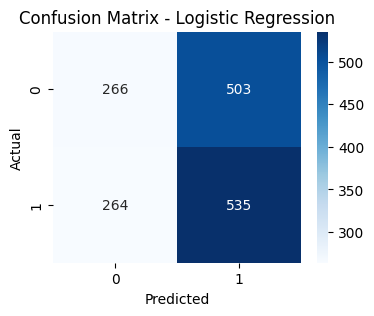

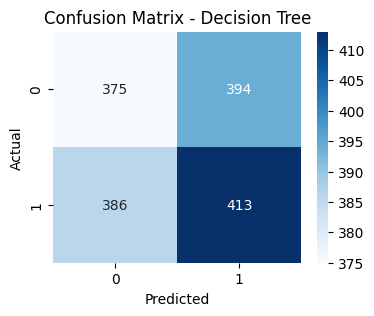

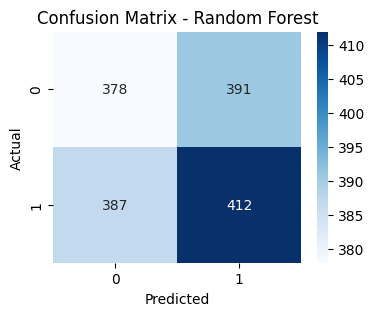

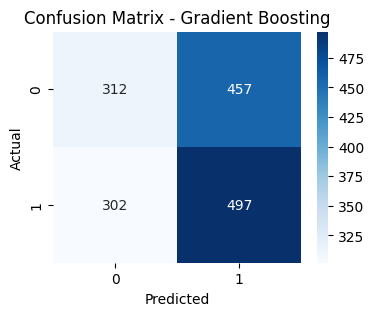

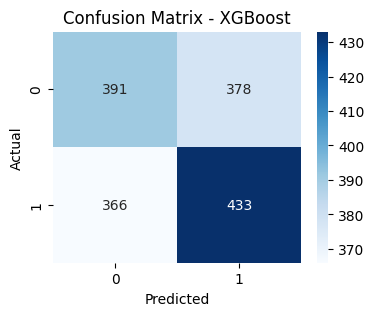

In [26]:
# Matrices de confusion des modèles de classification

# Boucle sur chaque modèle entraîné

for name, model in models.items():
    
#Génération des prédictions sur le jeu de test
    
    Y_pred = model.predict(X_test)

# Calcul de la matrice de confusion

    cm = confusion_matrix(Y_test, Y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Parmi les modèles évalués, la régression logistique obtient les meilleures performances. Toutefois, celles-ci restent limitées, avec une accuracy de 51% et un F1-score de 0,58% pour la classe des utilisateurs revenants. La matrice de confusion montre que le modèle identifie correctement une partie des utilisateurs revenants, mais au prix d'un nombre important de faux positifs. Ces résultats suggèrent que les variables explicatives disponibles ne permettent pas de discriminer efficacement les utilisateurs revenants des nouveaux utilisateurs. En conséquence, les modèles de classification testés présentent un pouvoir prédictif limité sur ce jeu de données.

In [27]:
# Optimisation des hyperparamètres avec GridSearchCV

# Définition des modèles et des paramètres à tester

param_grids = {

# Régression logistique
    # C contrôle la régularisation :
    # - petite valeur : modèle plus simple, moins de risque de surapprentissage
    # - grande valeur : modèle plus flexible
    # solver définit l'algorithme utilisé pour l'optimisation.

    "Logistic Regression": {
        "model": LogisticRegression(random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"],
            "penalty": ["l2"]
        }
    },

# Arbre de décision
    # max_depth limite la profondeur de l'arbre.
    # Une profondeur élevée peut provoquer du surapprentissage.
    #
    # min_samples_split indique le nombre minimum d'observations
    # nécessaires pour créer une nouvelle séparation.
    #
    # min_samples_leaf contrôle la taille minimale des feuilles.

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5]
        }
    },

#Random Forest
    # n_estimators correspond au nombre d'arbres construits.
    #
    # max_depth contrôle la complexité des arbres.
    #
    # Les paramètres min_samples_split et min_samples_leaf
    # permettent de limiter le surapprentissage.

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },

# Gradient Boosting
    # n_estimators correspond au nombre d'arbres ajoutés.
    # learning_rate contrôle l'importance de chaque nouvel arbre.
    # Une valeur faible nécessite généralement plus d'arbres.
    # max_depth contrôle la complexité des arbres.

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },

  # XGBoost
    # XGBoost est une méthode de boosting optimisée.
    # subsample permet d'utiliser une partie des données
    # à chaque étape afin de réduire le surapprentissage.

    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5],
            "subsample": [0.8, 1.0]
        }
    }

}

# Recherche des meilleurs paramètres

results = []

best_models = {}

# Boucle sur chaque modèle à optimiser

for name, config in param_grids.items():

    print(f"\nRecherche des meilleurs paramètres pour {name}...")

    # Création du GridSearch

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

# Entraînement du GridSearch

    grid.fit(X_train, Y_train)

    best_model = grid.best_estimator_

    best_models[name] = best_model

# Prédiction sur le jeu de test

    y_pred = best_model.predict(X_test)

 # Sauvegarde des résultats

    results.append({

        "Model": name,

        "Best CV F1": grid.best_score_,

        "Accuracy": accuracy_score(Y_test, y_pred),

        "Precision": precision_score(Y_test, y_pred),

        "Recall": recall_score(Y_test, y_pred),

        "F1-score": f1_score(Y_test, y_pred),

        "Best Parameters": grid.best_params_

    })

# Tableau final de comparaison

results_df = pd.DataFrame(results)

#Classement des modèles selon leur F1-score obtenu sur le test

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
)

display(results_df.round(4))


Recherche des meilleurs paramètres pour Logistic Regression...


c:\Users\vavro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



Recherche des meilleurs paramètres pour Decision Tree...

Recherche des meilleurs paramètres pour Random Forest...

Recherche des meilleurs paramètres pour Gradient Boosting...

Recherche des meilleurs paramètres pour XGBoost...


,Model,Best CV F1,Accuracy,Precision,Recall,F1-score,Best Parameters
3,Gradient Boosting,0.6217,0.5140,0.5138,0.8611,0.6436,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
4,XGBoost,0.6125,0.5128,0.5135,0.8310,0.6348,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
0,Logistic Regression,0.5865,0.5153,0.5184,0.6859,0.5905,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}"
2,Random Forest,0.5539,0.5287,0.5318,0.6270,0.5755,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
1,Decision Tree,0.6299,0.5134,0.5323,0.3717,0.4377,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s..."


Le GridSearchCV a permis d'améliorer les performances des modèles en optimisant leurs hyperparamètres. Parmi les modèles évalués, le Gradient Boosting obtient le meilleur F1-score (0.6436), tandis que la Random Forest présente la meilleure accuracy (0.5287). Toutefois, les performances globales restent modestes. En particulier, le Gradient Boosting présente un rappel très élevé (86 %), mais une précision limitée (51 %), traduisant une tendance à prédire un grand nombre d'utilisateurs comme revenants. Ces résultats suggèrent que les variables explicatives disponibles ne permettent pas de discriminer efficacement les utilisateurs revenants des nouveaux utilisateurs.

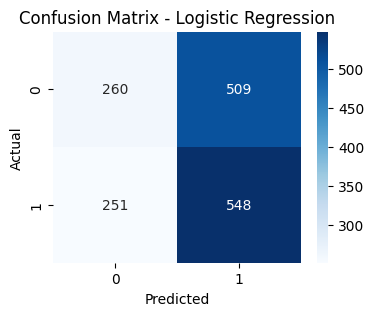

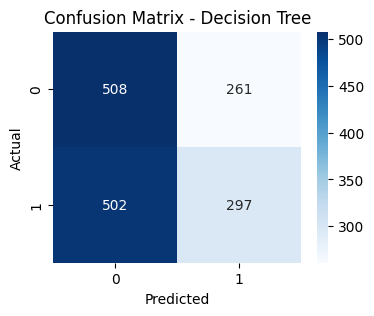

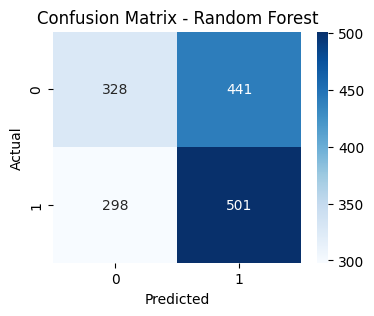

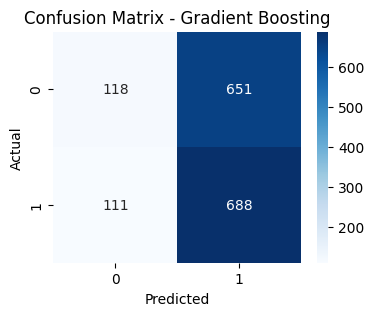

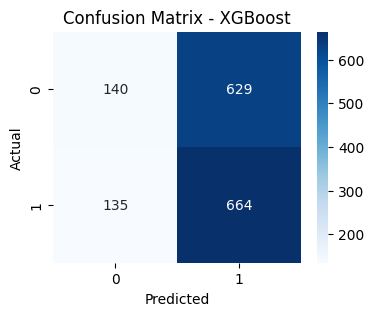

In [28]:
# Matrices de confusion des modèles de classification avec les nouveaux hyperparamètres optimisés

# Boucle sur chaque modèle entraîné

for name, model in best_models.items():
    
#Génération des prédictions sur le jeu de test
    
    Y_pred = model.predict(X_test)

# Calcul de la matrice de confusion

    cm = confusion_matrix(Y_test, Y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

['num__age' 'num__time_on_site' 'num__pages_viewed'
 'num__previous_purchases' 'num__cart_items' 'num__bounce_rate'
 'cat__gender_Male' 'cat__device_type_Mobile' 'cat__device_type_Tablet'
 'cat__discount_seen_Oui' 'cat__ad_clicked_Oui' 'cat__purchase_Oui']


,Variable,Importance
7,cat__device_type_Mobile,0.165352
5,num__bounce_rate,0.131280
4,num__cart_items,0.118426
1,num__time_on_site,0.116265
0,num__age,0.107890
3,num__previous_purchases,0.104815
2,num__pages_viewed,0.103823
8,cat__device_type_Tablet,0.076093
9,cat__discount_seen_Oui,0.076056
6,cat__gender_Male,0.000000


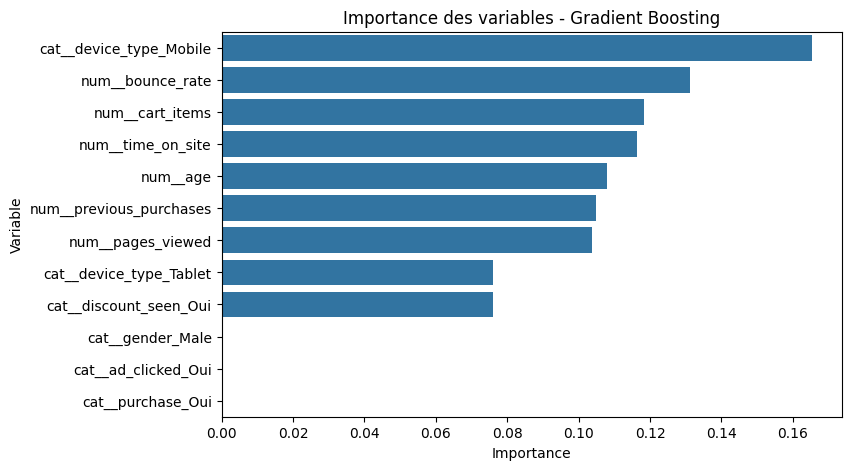

In [29]:
# Analyse de l'importance des variables avec le modèle Gradient Boosting

# Récupération des noms des variables après le prétraitement

feature_names = preprocessor.get_feature_names_out()

# Affichage des variables utilisées par le modèle

print(feature_names)

# Création d'un DataFrame

importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

#Visualisation de l'importance des variables

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Variable"
)

plt.title("Importance des variables - Gradient Boosting")
plt.show()

L’analyse des importances du Gradient Boosting montre que le type d’appareil mobile, le taux de rebond, le nombre d’articles dans le panier et le temps passé sur le site sont les variables les plus importantes pour prédire le retour des utilisateurs. À l’inverse, les variables liées au genre, aux clics publicitaires et à l’achat n’apportent aucune contribution dans ce modèle. Ces résultats permettent ainsi d’identifier les principaux facteurs comportementaux associés à la fidélisation des utilisateurs.

# Prédiction de la probabilité de retour d'un nouvel utilisateur

In [30]:
#Création d'un DataFrame contenant les informations d'un nouvel utilisateur.
#Les variables doivent avoir exactement les mêmes noms et le même format que les données utilisées lors de l'entraînement du modèle.

nouvel_utilisateur = pd.DataFrame({
    "age": [35],
    "gender": ["Female"],
    "device_type": ["Mobile"],
    "time_on_site": [180],
    "pages_viewed": [1],
    "previous_purchases": [0],
    "cart_items": [3],
    "discount_seen": ["Non"],
    "ad_clicked": ["Non"],
    "bounce_rate": [0.25],
    "purchase": [0]
})

# Application du même prétraitement que celui utilisé
# pour les données d'entraînement :
#
# - remplacement des valeurs manquantes
# - standardisation des variables numériques
# - encodage One-Hot des variables catégorielles
#
# Il est important d'utiliser "transform" uniquement,
# et non "fit_transform", afin de conserver les paramètres
# appris sur le jeu d'entraînement.

nouvel_utilisateur_prepared = preprocessor.transform(nouvel_utilisateur)

# Calcul de la probabilité d'appartenance à chaque classe
#
# predict_proba retourne deux probabilités :
#
# colonne 0 --> probabilité que l'utilisateur ne revienne pas
# colonne 1 --> probabilité que l'utilisateur revienne

proba = best_model.predict_proba(nouvel_utilisateur_prepared)

print(proba)
print(f"Probabilité de retour : {proba[0][1]:.2%}")

[[0.4690315 0.5309685]]
Probabilité de retour : 53.10%


c:\Users\vavro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Le modèle peut être utilisé non seulement pour prédire si un utilisateur est susceptible de revenir sur le site, mais également comme un outil d'aide à la décision pour orienter les actions marketing. En estimant la probabilité de retour de chaque utilisateur, il devient possible de mettre en place des stratégies différenciées. Par exemple, les utilisateurs présentant une probabilité de retour supérieure à 80 % pourraient être ciblés par un programme de fidélité afin de renforcer leur engagement, tandis que ceux dont la probabilité de retour est inférieure à 40 % pourraient faire l'objet d'une campagne de réengagement, par le biais d'offres promotionnelles ou de communications personnalisées.

### CONCLUSION

Dans cette étude, plusieurs modèles de classification ont été développés et comparés afin de prédire si un utilisateur est un utilisateur revenant. Les modèles évalués incluent la régression logistique, l'arbre de décision, la forêt aléatoire, le Gradient Boosting et XGBoost. Une phase d'optimisation des hyperparamètres à l'aide de GridSearchCV a ensuite été réalisée afin d'améliorer leurs performances.

Parmi les modèles testés, le Gradient Boosting s'est révélé être le plus performant, obtenant le meilleur F1-score. L'optimisation des hyperparamètres a permis une légère amélioration des performances, confirmant l'intérêt de cette étape dans le processus de modélisation. Toutefois, les résultats restent globalement modérés, avec une capacité de prédiction limitée. Ces performances suggèrent que les variables disponibles ne permettent pas de capturer pleinement les facteurs expliquant le retour des utilisateurs.

L'analyse de l'importance des variables montre que les facteurs les plus influents pour prédire le retour d'un utilisateur sont l'utilisation d'un appareil mobile (device_type_Mobile), le taux de rebond (bounce_rate), le nombre d'articles ajoutés au panier (cart_items), le temps passé sur le site (time_on_site) et l'âge (age). Les variables liées aux achats précédents (previous_purchases), au nombre de pages consultées (pages_viewed), à l'utilisation d'une tablette (device_type_Tablet) et à la consultation d'une promotion (discount_seen) présentent également une contribution non négligeable. Ces résultats indiquent que le retour d'un utilisateur est principalement expliqué par son comportement de navigation et son niveau d'engagement, tout en soulignant l'influence du type d'appareil utilisé et, dans une moindre mesure, de l'âge.

Malgré ces observations, cette étude présente certaines limites. Le modèle repose sur un nombre relativement restreint de variables explicatives (11 variables), ce qui limite sa capacité à représenter la complexité du comportement des utilisateurs. D'autres informations susceptibles d'améliorer les performances n'étaient pas disponibles dans le jeu de données, notamment l'historique détaillé des sessions, la fréquence des visites, la date de la dernière connexion, le nombre total d'interactions avec le site, les catégories de produits consultés, la source d'acquisition des utilisateurs (SEO, publicité, réseaux sociaux) ou encore les informations relatives aux paniers abandonnés.

En conclusion, les résultats obtenus montrent qu'il est possible de prédire, dans une certaine mesure, le retour d'un utilisateur à partir de données comportementales. Toutefois, les performances des modèles indiquent que des variables plus riches et plus représentatives du parcours utilisateur seraient nécessaires pour améliorer la qualité des prédictions. Ces perspectives constituent des pistes d'amélioration intéressantes pour de futurs travaux portant sur la fidélisation et la prédiction du comportement des utilisateurs.